In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import random

In [2]:
fixed_iv = np.load('fixed_iv_full_algo_new220k.npy')
fixed_iv = np.array(fixed_iv)
fixed_traces = np.load('fixed_traces_full_algo_new220k.npy')
fixed_traces = np.array(fixed_traces)
rand_iv = np.load('rand_iv_full_algo_new220k.npy')
rand_iv = np.array(rand_iv)
rand_traces = np.load('rand_traces_full_algo_new220k.npy')
rand_traces = np.array(rand_traces)

In [34]:
r = random.random()
print(r)

0.6589785425262323


In [35]:
a = fixed_traces[1]
print(np.shape(a))
print(a)

(20000,)
[ 0.0234375  -0.09375    -0.06542969 ... -0.08789062 -0.078125
 -0.06933594]


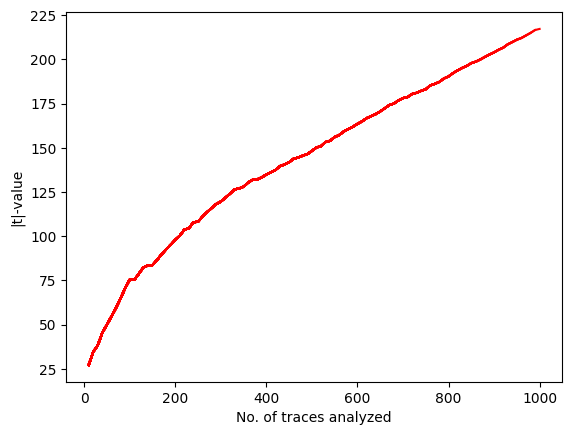

In [5]:
num_trace_pairs = fixed_iv.shape[0]
update_per = 10
start = 10
avg = 0.5

tval_hist = np.zeros(num_trace_pairs//update_per)

fig, ax = plt.subplots()

for i in range(start, num_trace_pairs+1, update_per):
    result = stats.ttest_ind(fixed_traces[:i,:], rand_traces[:i,:], equal_var=False)
    tval_hist[i//update_per-1] = np.max(result.statistic)
    t = np.arange(start*2*avg, i*2*avg+1, start*2*avg) 
    ax.plot(t,tval_hist[:i//update_per], 'r')
#plt.ylim([0, 150])
plt.xlabel('No. of traces analyzed')
plt.ylabel('|t|-value')
plt.show()

In [37]:
result = stats.ttest_ind(fixed_traces, rand_traces, equal_var=False)

In [38]:
print(result)

Ttest_indResult(statistic=array([ 3.5730633 ,  5.79251556, -3.12399056, ...,  3.52132856,
        3.34118925, -1.74949351]), pvalue=array([3.61191899e-04, 8.03633693e-09, 1.80976814e-03, ...,
       4.39019934e-04, 8.49574488e-04, 8.03593206e-02]))


In [39]:
print(np.shape(result))

(2, 20000)


Text(0, 0.5, '|t|-value')

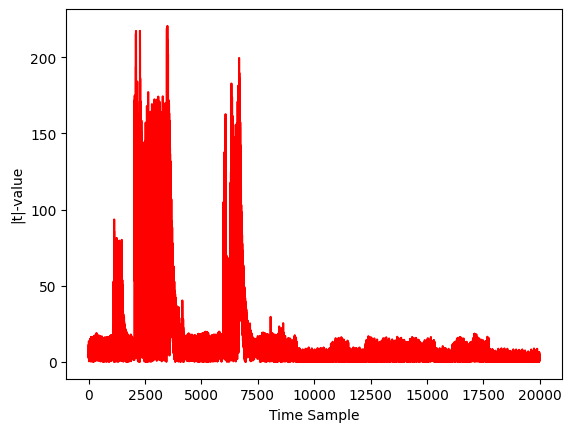

In [40]:
a = abs(result[0])
#fig, ax = plt.subplots()
plt.plot(a, color = 'r')
#plt.ylim([0,2])
plt.xlabel('Time Sample')
plt.ylabel('|t|-value')
#plt.savefig('tvla assembly_new.svg')

In [262]:
print((a[0]))

5.823789369220771e-06
